# Tutorial 6: Scalability analysis on million-scale Visium HD datasets

In this tutorial, we challenged STADIM with a million-scale dataset from the 10x Visium HD platform to demonstrate its prowess in handling ultra-high-resolution spatial data.  
We download the data via https://www.10xgenomics.com/platforms/visium/product-family/dataset-human-crc.

## Quick view data

/home/xiaost/anaconda3/envs/stadim/lib/python3.9/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/xiaost/anaconda3/envs/stadim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


P1CRC
AnnData object with n_obs × n_vars = 507684 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


/home/xiaost/anaconda3/envs/stadim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


P2CRC
AnnData object with n_obs × n_vars = 545913 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


/home/xiaost/anaconda3/envs/stadim/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


P5CRC
AnnData object with n_obs × n_vars = 541968 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


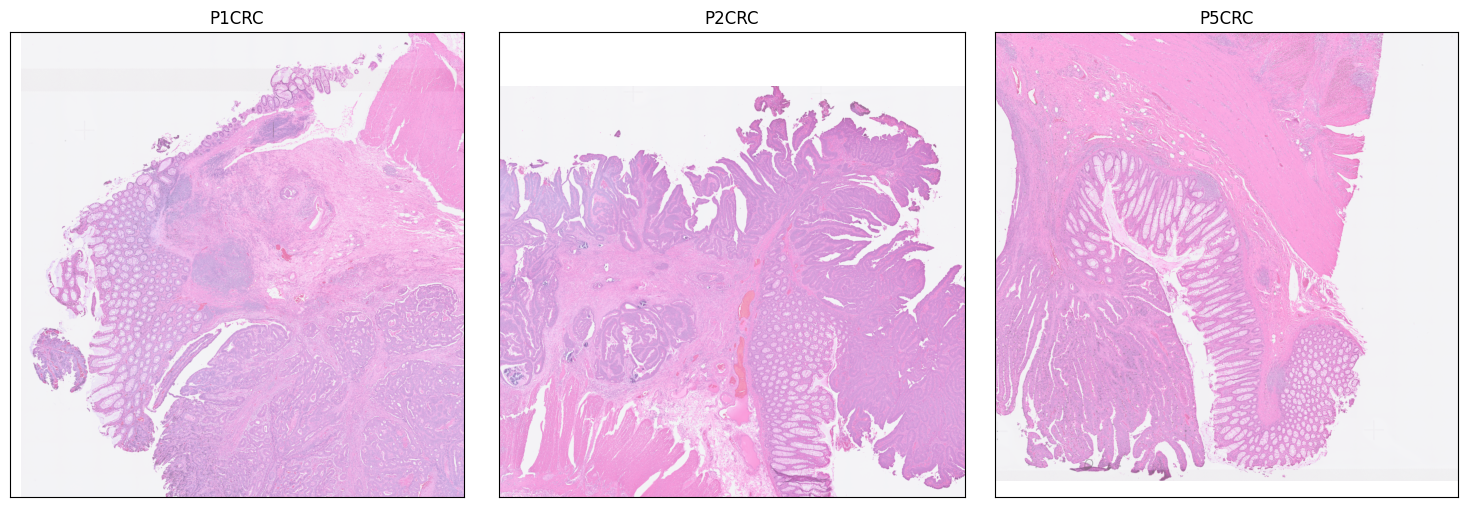

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import os

sample_ids = ['P1CRC', 'P2CRC', 'P5CRC']
data_dir = '/data2/xiaost/SODA/Data/CRC_VisiumHD/'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, s_id in enumerate(sample_ids):
    adata = sc.read_h5ad(os.path.join(data_dir, f'{s_id}.h5ad'))
    print(f'{s_id}')
    print(adata)
    sc.pl.spatial(adata, library_id=s_id, alpha_img=0.6, ax=axes[i], show=False, title=s_id)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Run STADIM

**Note: For large-scale datasets, we strongly recommend running STADIM as a background process via the `stadim` command-line interface.**  

You can call the STADIM command directly in your terminal:
```bash
nohup stadim --input "./P1CRC.h5ad" "./P2CRC.h5ad" "./P5CRC.h5ad" --save_dir ./CRC_VisiumHD_test --device "cuda:0" --monitor --seed 2026 --min_genes 50 --min_cells 10 --knn_c 30 --knn_e 70 --mnn_n 100 > ./CRC_VisiumHD_test.log 2>&1 &
```
and load the results into your Python environment for downstream analysis.  

```python
import anndata as ad

adata = ad.read_h5ad('/CRC_VisiumHD_test/sdata.h5ad')

## The denoised gene expressionis is stored in adata.layers['STADIM']
print(adata)
```
**Note: For datasets exceeding a size threshold of 10^10, denoised expression matrices are not stored to reduce memory and storage overhead. The learned latent representations remain available in `adata.obsm['STADIM']`.**

This dataset contained **1,595,565 spots × 18,085 genes** before filtering and **1,284,457 spots × 18,065 genes** after filtering.  
**STADIM** required approximately **560.8 minutes runtime, 341 GB RAM, and 2.9 GB GPU memory**.  

Here, we directly load the pre-trained model and STADIM results to illustrate how to extract denoised data for specific gene sets of interest.

In [ ]:
import os
import gc
import torch
import numpy as np
import scanpy as sc
from scipy.sparse import issparse

# ===================== 1. User settings =====================

device = "cuda:0"

model_path = "/path/to/trained_model.pth"
adata_path = "/path/to/sdata.h5ad"
save_path = "/path/to/interest_gene_set_denoised.h5ad"

input_layer = "X_norm"
batch_key = "sample"

gene_sets = {
    'Tumor': ['CEACAM6', 'MYC', 'LCN2', 'CLDN4', 'REG1A', 'MUC17'],
    'Epithelial': ['PIGR', 'OLFM4', 'MUC12', 'SELENOP'],
    'Stroma': ['COL1A1', 'COL3A1', 'DES', 'TAGLN', 'DCN', 'SFRP2'],
    'Vasculature': ['PLVAP', 'ESAM', 'PECAM1', 'VWF'], 
    'Immune': ['CD74', 'TRAC', 'IGKC', 'JCHAIN', 'SPP1', 'CD68']
}

eval_batch_size = 4096
loss_mode = "nb"
seed = 2026

# ===================== 2. Load data =====================

adata = sc.read_h5ad(adata_path)
X_input = adata.layers[input_layer]

# Merge and filter genes of interest
genes_of_interest = sorted(set(g for genes in gene_sets.values() for g in genes))
valid_genes = [g for g in genes_of_interest if g in adata.var_names]
gene_indices = [adata.var_names.get_loc(g) for g in valid_genes]

print(f"Requested genes: {len(genes_of_interest)}")
print(f"Valid genes found: {len(valid_genes)}")

# Batch information
batches = np.asarray(adata.obs[batch_key].astype("category").cat.codes)
n_batches = len(np.unique(batches))
max_val = float(X_input.max())

# ===================== 3. Load trained model =====================

import stadim

model = stadim.STADIM(input_dim=adata.n_vars, n_batches=n_batches,
                      encoder_layers=[512, 256, 64], decoder_layers=[1000],distribution=loss_mode, seed=seed)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# ===================== 4. Denoise selected genes only =====================

n_cells = adata.n_obs
n_target_genes = len(valid_genes)

denoised_genes = np.zeros((n_cells, n_target_genes), dtype=np.float32)

print("Generating denoised expression for selected genes...")

with torch.no_grad():
    for start_idx in range(0, n_cells, eval_batch_size):
        end_idx = min(start_idx + eval_batch_size, n_cells)

        batch_raw = X_input[start_idx:end_idx]
        if issparse(batch_raw):
            batch_raw = batch_raw.toarray()

        input_tensor = torch.from_numpy(batch_raw).float().to(device)
        current_bs = input_tensor.shape[0]

        # Marginalization over all batches
        chunk_sum = np.zeros((current_bs, n_target_genes), dtype=np.float32)

        for b_id in range(n_batches):
            fake_batch_idx = torch.full((current_bs,), b_id, dtype=torch.long, device=device)

            if loss_mode == "nb":
                _, output, _ = model(input_tensor, batch_index=fake_batch_idx)
            else:
                _, output, _, _ = model(input_tensor, batch_index=fake_batch_idx)

            chunk_sum += np.clip(output[:, gene_indices].cpu().numpy(), a_min=None, a_max=max_val)

        denoised_genes[start_idx:end_idx] = chunk_sum / n_batches

        del input_tensor, fake_batch_idx, output
        torch.cuda.empty_cache()

        if start_idx % (eval_batch_size * 10) == 0:
            print(f"Processed {end_idx}/{n_cells} cells")

gc.collect()
torch.cuda.empty_cache()

# ===================== 5. Save as AnnData with layers['STADIM'] =====================

adata_subset = adata[:, valid_genes].copy()
adata_subset.layers["STADIM"] = denoised_genes

os.makedirs(os.path.dirname(save_path), exist_ok=True)
adata_subset.write_h5ad(save_path)

print(f"Saved denoised gene-set data to: {save_path}")
print("Denoised data is available at: adata_subset.layers['STADIM']")